# Astlingen Rainfall GMM Stratified Block Time Series Split (SBTSS) & Experiment Version Tracking

This notebook reproduces the Gaussian Mixture Model (GMM) clustering and stratified block time-series split pipeline for the **Astlingen Erft precipitation dataset** (2000–2009) and provides **reproducible experiment version tracking** across multiple model configurations.

### Objectives
1. **Data Loading & Merging**: Load 4 rain gauge telemetry files (`1Astlingen_Erft1.csv`, `2Astlingen_Erft2.csv`, `3Astlingen_Erft3.csv`, `4Astlingen_Erft4.csv`) from `../data/rainfall/astlingen/` and compute station-average 5-minute rainfall (`avg_rainfall`).
2. **14-Day Block Partitioning**: Divide the continuous 10-year 5-minute time series (1,051,200 intervals) into 260 non-overlapping 14-day blocks ($14 \text{ days} \times 24 \text{ hrs} \times 12 \text{ intervals/hr} = 4,032$ steps/block).
3. **Modular Experiment Pipeline**: Define a parameterized end-to-end pipeline supporting arbitrary combinations of HMM seasonal states (`HMM_STATES`), GMM component counts (`GMM_K`), and optional HMM feature integration.
4. **Multi-Feature Model Selection & Extended K Evaluation ($K \in [1, 15]$)**: Evaluate candidate $K \in [1, 15]$ across all feature representations (No-HMM 3D, 4-State HMM 4D, and 5-State HMM 4D) with explicit markers for $K=4$ and $K=5$.
5. **Version Tracking & Multi-Experiment Execution**: Run and compare six key experiment configurations:
   - **Baseline (`hmm4_k4`)**: 4 HMM states, 4 GMM regimes ($K=4$).
   - **Version A (`hmm5_k4`)**: 5 HMM states, 4 GMM regimes ($K=4$).
   - **Version B (`hmm4_k5`)**: 4 HMM states, 5 GMM regimes ($K=5$).
   - **Version C (`hmm5_k5`)**: 5 HMM states, 5 GMM regimes ($K=5$).
   - **Version D (`nohmm_k4`)**: No HMM feature (3D physical metrics), 4 GMM regimes ($K=4$).
   - **Version E (`nohmm_k5`)**: No HMM feature (3D physical metrics), 5 GMM regimes ($K=5$).
6. **Version-Specific Subdirectory Exports**: Export version-tagged CSV datasets (`train_{version}.csv`, `val_{version}.csv`, `test_{version}.csv`, `astlingen_block_profiles_{version}.csv`) under `../data/rainfall/astlingen/splits/14day_blocks/{version}/`.
7. **UMAP & Feature Distribution Visualizations**: Render UMAP 2D latent space projections and 4-panel feature distribution boxplots for all six experiment versions.


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from hmmlearn import hmm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
SEED = 42


## 1. Data Loading & 14-Day Block Partitioning

We load the 4 gauge CSV files from `../data/rainfall/astlingen/` and partition the continuous 1,051,200 intervals into 260 non-overlapping 14-day blocks (4,032 steps/block).


In [3]:
data_dir = Path("../data/rainfall/astlingen")
files = sorted(list(data_dir.glob("*Astlingen_Erft*.csv")))
if not files:
    raise FileNotFoundError(f"No Astlingen CSV files found in {data_dir}")

print(f"Found {len(files)} gauge files: {[f.name for f in files]}")
dfs = []
for f in files:
    df = pd.read_csv(f)
    df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"], format="%m/%d/%Y %H:%M:%S")
    df = df.set_index("datetime")
    val_col = [c for c in df.columns if c not in ["date", "time"]][0]
    gauge_id = f.stem
    dfs.append(df[[val_col]].rename(columns={val_col: gauge_id}))

df_merged = pd.concat(dfs, axis=1)
df_merged["avg_rainfall"] = df_merged.mean(axis=1)
df_full = df_merged.dropna(subset=["avg_rainfall"])
print(f"Merged continuous dataset shape: {df_full.shape}")

BLOCK_SIZE = 4032  # 14 days * 24 hrs * 12 intervals/hr
n_blocks = len(df_full) // BLOCK_SIZE
blocks = [df_full.iloc[i * BLOCK_SIZE : (i + 1) * BLOCK_SIZE] for i in range(n_blocks)]
print(f"Created {len(blocks)} blocks of size {BLOCK_SIZE}.")


Found 4 gauge files: ['1Astlingen_Erft1.csv', '2Astlingen_Erft2.csv', '3Astlingen_Erft3.csv', '4Astlingen_Erft4.csv']
Merged continuous dataset shape: (1051200, 5)
Created 260 blocks of size 4032.


## 2. Parameterized Experiment & Dataset Versioning Pipeline

We define `run_experiment_pipeline()` supporting optional HMM seasonality (`hmm_states > 0` vs `hmm_states = 0` for No-HMM 3D physical profiling).


In [5]:
def safe_stratified_split(df, stratify_col, test_size=0.2, random_state=42):
    """Performs stratified train_test_split, allocating rare singleton classes (<2 items) directly to train."""
    counts = df[stratify_col].value_counts()
    rare_classes = counts[counts < 2].index
    df_rare = df[df[stratify_col].isin(rare_classes)]
    df_regular = df[~df[stratify_col].isin(rare_classes)]
    
    if len(df_regular) > 0:
        df_train_reg, df_test_reg = train_test_split(
            df_regular, test_size=test_size, stratify=df_regular[stratify_col], random_state=random_state
        )
        df_train = pd.concat([df_train_reg, df_rare])
        df_test = df_test_reg
    else:
        df_train = df
        df_test = pd.DataFrame()
    return df_train, df_test

def run_experiment_pipeline(df_full, blocks, hmm_states, gmm_k, seed=42, export_prefix="hmm4_k4"):
    use_hmm = (hmm_states > 0)
    if use_hmm:
        daily = pd.DataFrame({
            "Total Rainfall": df_full["avg_rainfall"].resample("D").sum(),
            "Maximum Intensity": df_full["avg_rainfall"].resample("D").max(),
            "Rainy Fraction": df_full["avg_rainfall"].resample("D").apply(lambda x: (x > 0).mean())
        })
        smoothed = daily.rolling(window=14, center=True).mean().dropna()
        smoothed["doy"] = smoothed.index.dayofyear
        profile = smoothed.groupby("doy").mean()
        if 366 in profile.index:
            profile = profile.drop(index=366)

        scaler_hmm = StandardScaler()
        X_hmm = scaler_hmm.fit_transform(profile)
        model_hmm = hmm.GaussianHMM(n_components=hmm_states, covariance_type="full", n_iter=2000, random_state=seed)
        model_hmm.fit(X_hmm)
        states_hmm = model_hmm.predict(X_hmm)
        doy_to_season = {int(doy): int(state) for doy, state in zip(profile.index, states_hmm)}

    block_profiles = []
    for i, block in enumerate(blocks):
        zero_inflation = (block["avg_rainfall"] == 0).mean()
        total_accumulation = block["avg_rainfall"].sum()
        peak_intensity = block["avg_rainfall"].max()
        prof_dict = {
            "block_id": i,
            "zero_inflation": zero_inflation,
            "total_accumulation": total_accumulation,
            "peak_intensity": peak_intensity,
            "start_time": block.index.min(),
            "end_time": block.index.max()
        }
        if use_hmm:
            block_doys = block.index.dayofyear
            seasons = [doy_to_season.get(d, doy_to_season.get(365, 0)) for d in block_doys]
            dominant_season = int(pd.Series(seasons).mode()[0])
            prof_dict["season"] = dominant_season
        block_profiles.append(prof_dict)
    df_profiles = pd.DataFrame(block_profiles)

    features = ["zero_inflation", "total_accumulation", "peak_intensity"]
    if use_hmm:
        features.append("season")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_profiles[features])

    gmm = GaussianMixture(n_components=gmm_k, covariance_type="full", random_state=seed)
    df_profiles["gmm_regime"] = gmm.fit_predict(X_scaled)

    kmeans = KMeans(n_clusters=gmm_k, random_state=seed)
    df_profiles["stratum"] = kmeans.fit_predict(X_scaled)

    sil_gmm = silhouette_score(X_scaled, df_profiles["gmm_regime"])
    db_gmm = davies_bouldin_score(X_scaled, df_profiles["gmm_regime"])
    sil_kmeans = silhouette_score(X_scaled, df_profiles["stratum"])
    db_kmeans = davies_bouldin_score(X_scaled, df_profiles["stratum"])

    df_train, df_temp = safe_stratified_split(df_profiles, "gmm_regime", test_size=0.2, random_state=seed)
    df_val, df_test = safe_stratified_split(df_temp, "gmm_regime", test_size=0.5, random_state=seed)

    df_profiles.loc[df_train.index, "split_label"] = "train"
    df_profiles.loc[df_val.index, "split_label"] = "val"
    df_profiles.loc[df_test.index, "split_label"] = "test"

    version_dir = Path(f"../data/rainfall/astlingen/splits/14day_blocks/{export_prefix}")
    version_dir.mkdir(parents=True, exist_ok=True)
    
    profiles_path = version_dir / f"astlingen_block_profiles_{export_prefix}.csv"
    df_profiles.to_csv(profiles_path, index=False)

    train_block_ids = set(df_train["block_id"])
    val_block_ids = set(df_val["block_id"])
    test_block_ids = set(df_test["block_id"])

    df_train_5min = pd.concat([blocks[i] for i in sorted(train_block_ids)])
    df_val_5min = pd.concat([blocks[i] for i in sorted(val_block_ids)])
    df_test_5min = pd.concat([blocks[i] for i in sorted(test_block_ids)])

    df_train_5min["split_label"] = "train"
    df_val_5min["split_label"] = "val"
    df_test_5min["split_label"] = "test"

    train_path = version_dir / f"train_{export_prefix}.csv"
    val_path = version_dir / f"val_{export_prefix}.csv"
    test_path = version_dir / f"test_{export_prefix}.csv"

    df_train_5min.to_csv(train_path)
    df_val_5min.to_csv(val_path)
    df_test_5min.to_csv(test_path)

    return {
        "version": export_prefix,
        "hmm_states": hmm_states if use_hmm else "None (3D)",
        "gmm_k": gmm_k,
        "sil_gmm": sil_gmm,
        "db_gmm": db_gmm,
        "sil_kmeans": sil_kmeans,
        "db_kmeans": db_kmeans,
        "train_rows": len(df_train_5min),
        "val_rows": len(df_val_5min),
        "test_rows": len(df_test_5min),
        "df_profiles": df_profiles,
        "X_scaled": X_scaled,
        "gmm": gmm,
        "profiles_path": str(profiles_path),
        "train_path": str(train_path),
        "val_path": str(val_path),
        "test_path": str(test_path)
    }

print("run_experiment_pipeline() defined successfully!")


run_experiment_pipeline() defined successfully!


### 2.1 HMM 365-Day Seasonal State Predictions Over Climatological Profiles

Below we plot the predicted HMM seasonal states (for both 4-State and 5-State HMM models) across all 365 Days-of-Year (DOY), overlaid on the 14-day smoothed climatological profiles for Daily Total Rainfall (mm), Maximum 5-Min Intensity (mm), and Rainy Fraction.


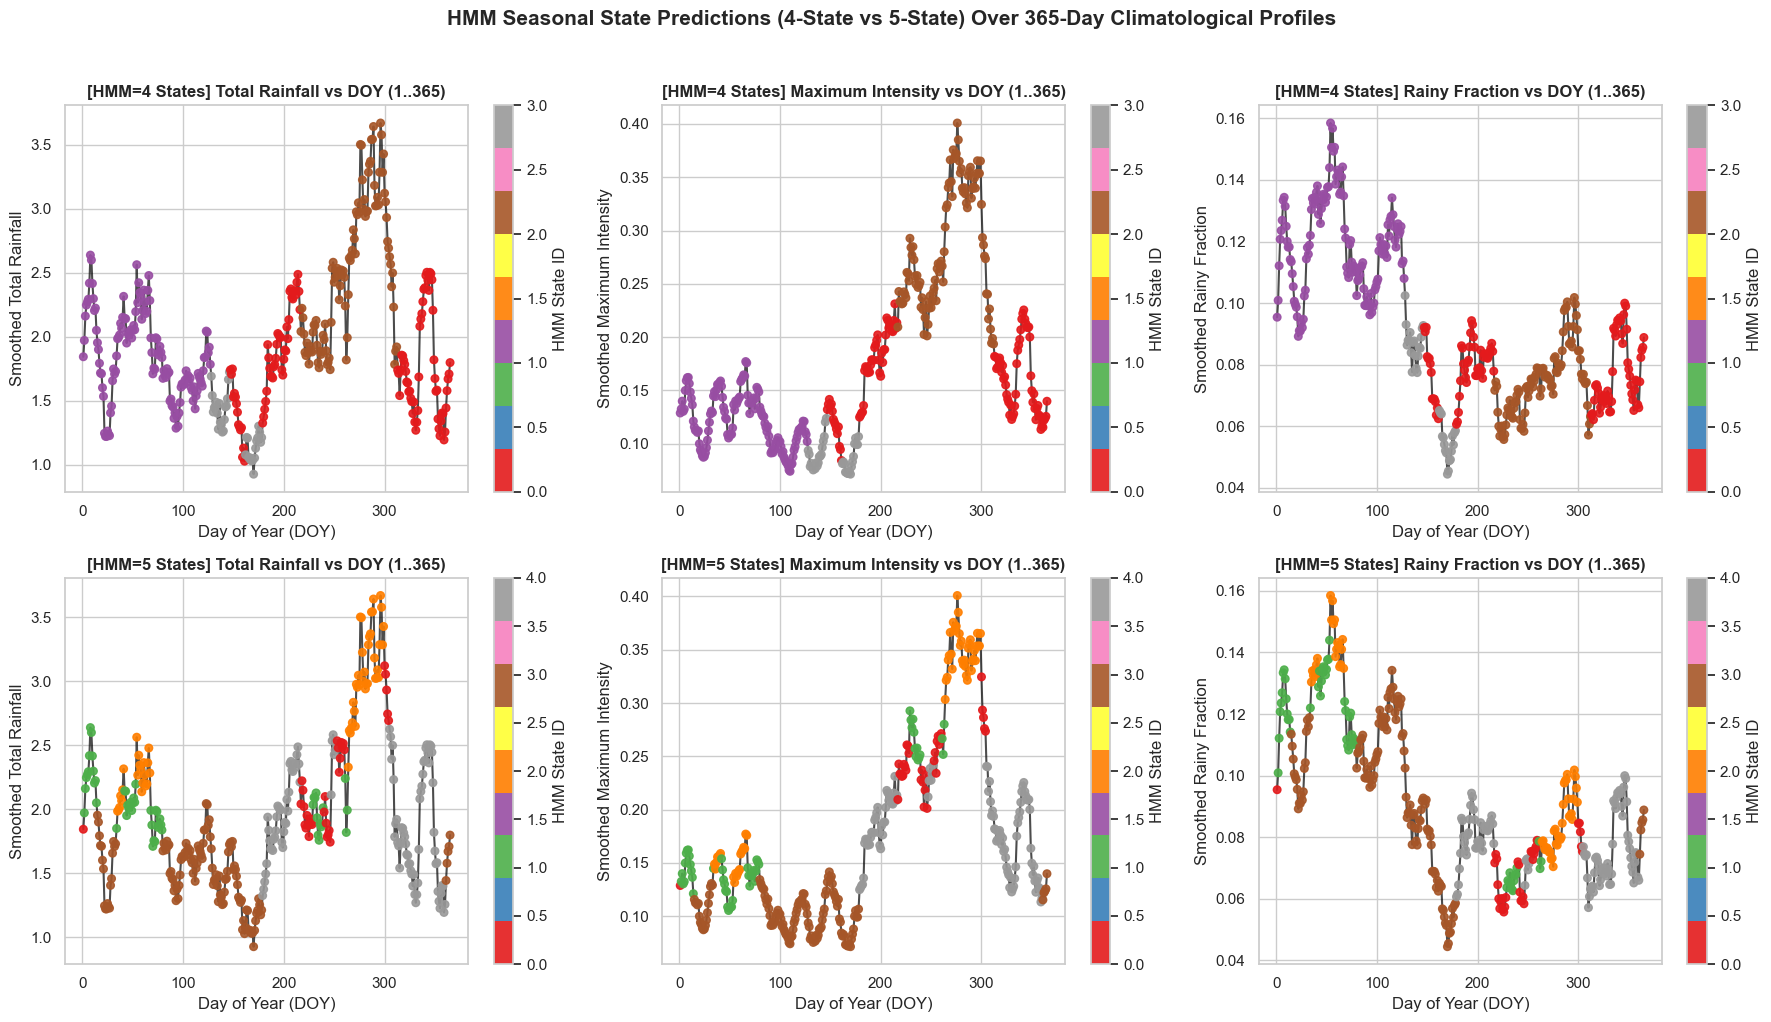

In [7]:
daily_clim = pd.DataFrame({
    "Total Rainfall": df_full["avg_rainfall"].resample("D").sum(),
    "Maximum Intensity": df_full["avg_rainfall"].resample("D").max(),
    "Rainy Fraction": df_full["avg_rainfall"].resample("D").apply(lambda x: (x > 0).mean())
})
smoothed_clim = daily_clim.rolling(window=14, center=True).mean().dropna()
smoothed_clim["doy"] = smoothed_clim.index.dayofyear
profile_clim = smoothed_clim.groupby("doy").mean()
if 366 in profile_clim.index:
    profile_clim = profile_clim.drop(index=366)

scaler_hmm = StandardScaler()
X_hmm_clim = scaler_hmm.fit_transform(profile_clim)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, n_states in enumerate([4, 5]):
    model_h = hmm.GaussianHMM(n_components=n_states, covariance_type="full", n_iter=2000, random_state=SEED)
    model_h.fit(X_hmm_clim)
    predicted_states = model_h.predict(X_hmm_clim)
    
    doys = profile_clim.index.values
    metrics = ["Total Rainfall", "Maximum Intensity", "Rainy Fraction"]
    
    for m_idx, col in enumerate(metrics):
        ax = axes[idx, m_idx]
        y_vals = profile_clim[col].values
        
        ax.plot(doys, y_vals, color="black", linewidth=1.5, alpha=0.7, label="14-Day Smoothed Profile")
        sc = ax.scatter(doys, y_vals, c=predicted_states, cmap="Set1", s=30, alpha=0.9, zorder=3)
        
        ax.set_title(f"[HMM={n_states} States] {col} vs DOY (1..365)", fontsize=12, fontweight="bold")
        ax.set_xlabel("Day of Year (DOY)")
        ax.set_ylabel(f"Smoothed {col}")
        fig.colorbar(sc, ax=ax, label="HMM State ID")

plt.suptitle("HMM Seasonal State Predictions (4-State vs 5-State) Over 365-Day Climatological Profiles", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 3. Extended Model Selection ($K \in [1, 15]$) Across All Feature Representations

We evaluate component counts $K \in [1, 15]$ across **all three feature representations**, highlighting markers for $K=4$ (dotted gray) and $K=5$ (dashed green):
1. **No-HMM (3D)**: `[zero_inflation, total_accumulation, peak_intensity]`
2. **4-State HMM (4D)**: `[zero_inflation, total_accumulation, peak_intensity, season_hmm4]`
3. **5-State HMM (4D)**: `[zero_inflation, total_accumulation, peak_intensity, season_hmm5]`


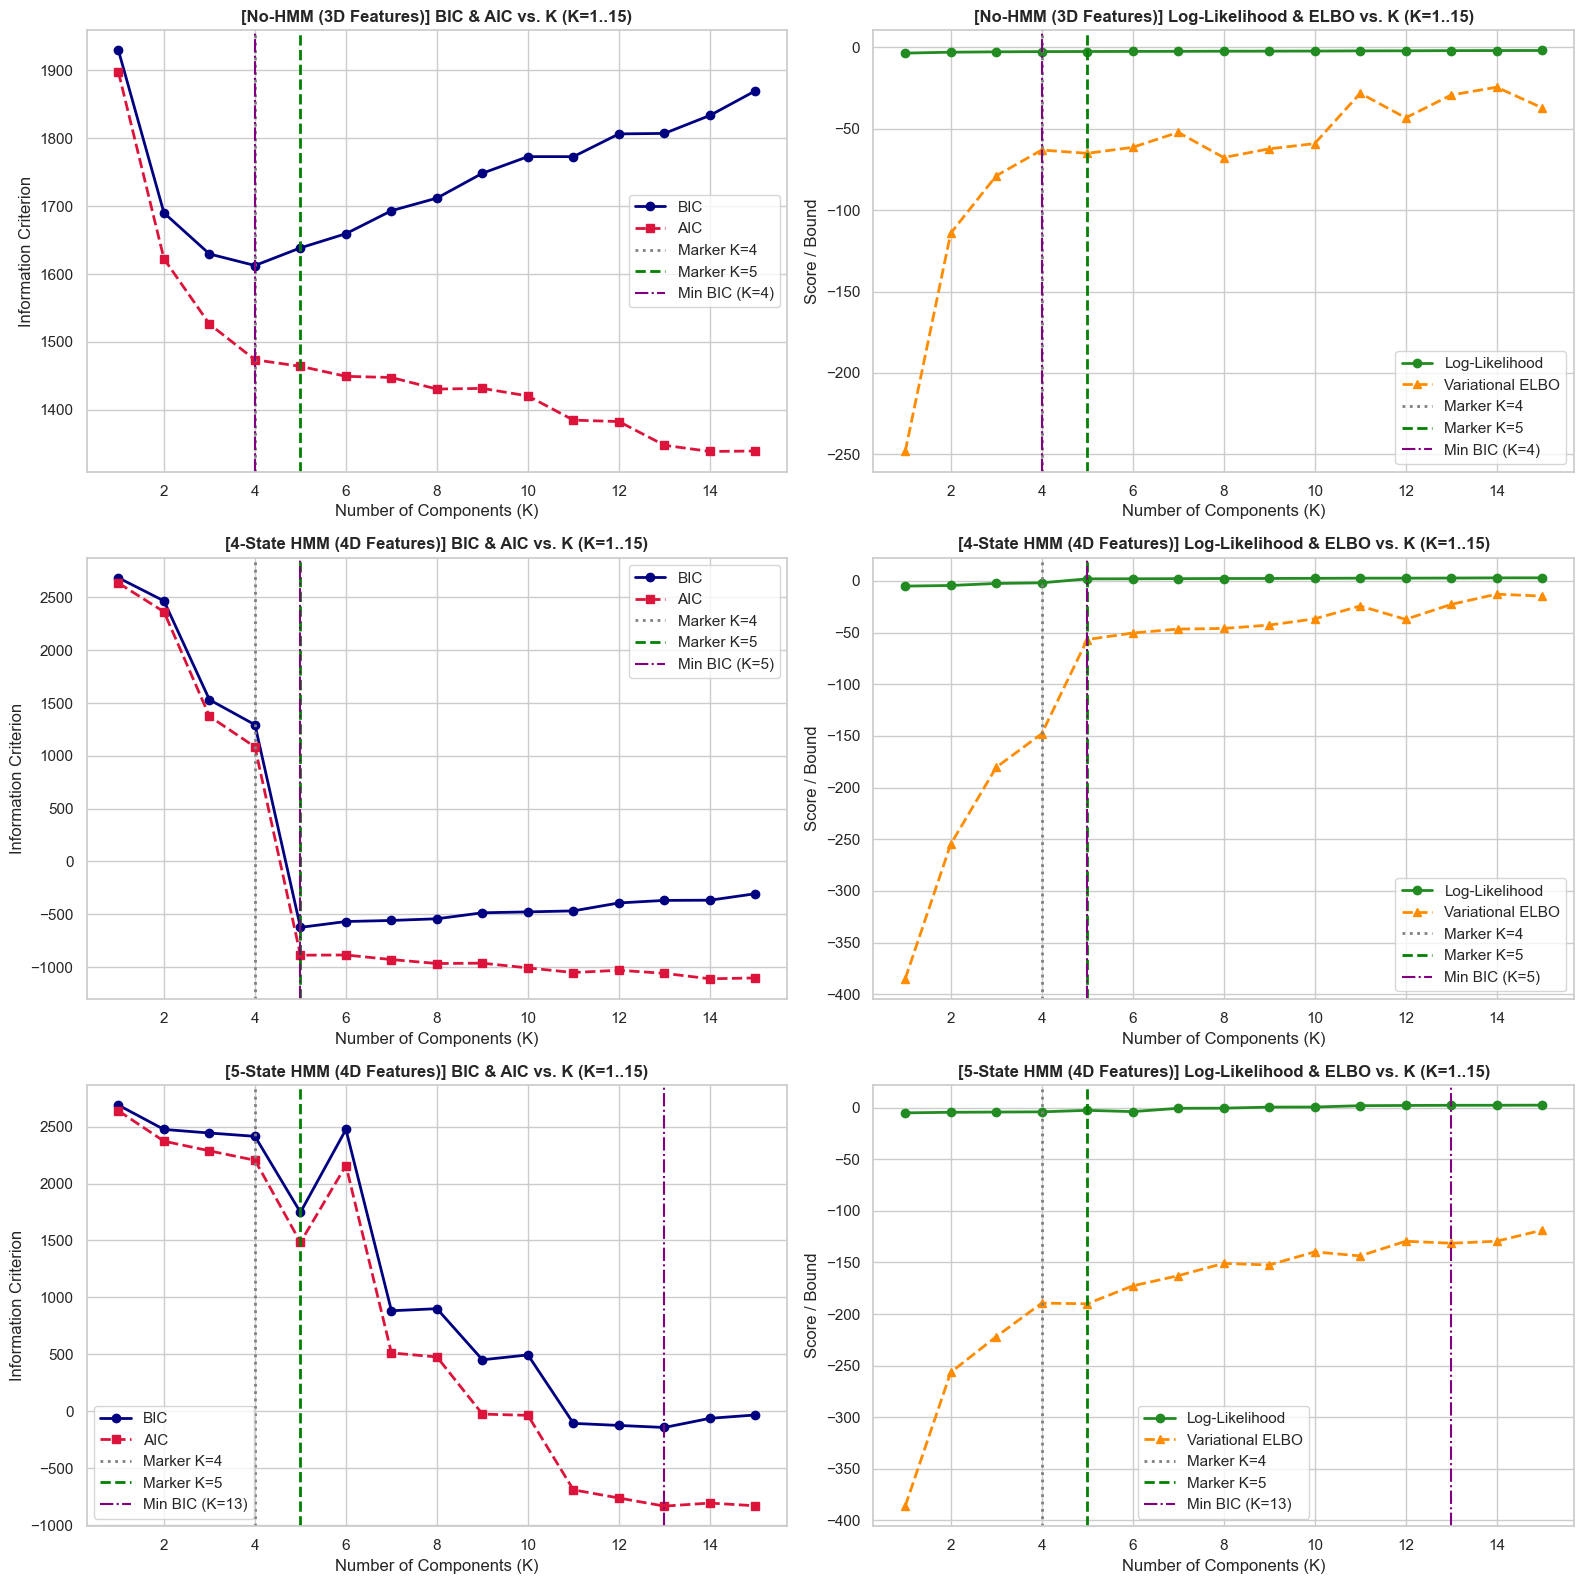

In [9]:
feature_configs = [
    ("No-HMM (3D Features)", 0, "nohmm_k4"),
    ("4-State HMM (4D Features)", 4, "hmm4_k4"),
    ("5-State HMM (4D Features)", 5, "hmm5_k4")
]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
k_range = range(1, 16)

for idx, (label_name, h_states, pref) in enumerate(feature_configs):
    res_f = run_experiment_pipeline(df_full, blocks, h_states, 4, seed=SEED, export_prefix=pref)
    X_sc = res_f["X_scaled"]
    
    bics, aics, log_liks, elbos, sils = [], [], [], [], []
    for k in k_range:
        gmm_k = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED, n_init=5)
        gmm_k.fit(X_sc)
        bics.append(gmm_k.bic(X_sc))
        aics.append(gmm_k.aic(X_sc))
        log_liks.append(gmm_k.score(X_sc))
        
        bgmm_k = BayesianGaussianMixture(
            n_components=k, covariance_type="full",
            weight_concentration_prior_type="dirichlet_process",
            random_state=SEED, n_init=5
        )
        bgmm_k.fit(X_sc)
        elbos.append(bgmm_k.lower_bound_)
        
        if k >= 2:
            sils.append(silhouette_score(X_sc, gmm_k.predict(X_sc)))
        else:
            sils.append(np.nan)
            
    min_bic_k = k_range[int(np.argmin(bics))]
    
    # Left plot: BIC & AIC
    axes[idx, 0].plot(k_range, bics, "o-", color="navy", linewidth=2, label="BIC")
    axes[idx, 0].plot(k_range, aics, "s--", color="crimson", linewidth=2, label="AIC")
    axes[idx, 0].axvline(x=4, color="gray", linestyle=":", linewidth=2, label="Marker K=4")
    axes[idx, 0].axvline(x=5, color="green", linestyle="--", linewidth=2, label="Marker K=5")
    axes[idx, 0].axvline(x=min_bic_k, color="purple", linestyle="-.", label=f"Min BIC (K={min_bic_k})")
    axes[idx, 0].set_title(f"[{label_name}] BIC & AIC vs. K (K=1..15)", fontsize=12, fontweight="bold")
    axes[idx, 0].set_xlabel("Number of Components (K)")
    axes[idx, 0].set_ylabel("Information Criterion")
    axes[idx, 0].legend()
    
    # Right plot: Log-Likelihood & Variational ELBO
    axes[idx, 1].plot(k_range, log_liks, "o-", color="forestgreen", linewidth=2, label="Log-Likelihood")
    axes[idx, 1].plot(k_range, elbos, "^--", color="darkorange", linewidth=2, label="Variational ELBO")
    axes[idx, 1].axvline(x=4, color="gray", linestyle=":", linewidth=2, label="Marker K=4")
    axes[idx, 1].axvline(x=5, color="green", linestyle="--", linewidth=2, label="Marker K=5")
    axes[idx, 1].axvline(x=min_bic_k, color="purple", linestyle="-.", label=f"Min BIC (K={min_bic_k})")
    axes[idx, 1].set_title(f"[{label_name}] Log-Likelihood & ELBO vs. K (K=1..15)", fontsize=12, fontweight="bold")
    axes[idx, 1].set_xlabel("Number of Components (K)")
    axes[idx, 1].set_ylabel("Score / Bound")
    axes[idx, 1].legend()

plt.tight_layout()
plt.show()


## 4. Multi-Experiment Execution & Dataset Version Tracking

We execute the pipeline across six target configurations:
1. **Baseline (`hmm4_k4`)**: 4 HMM states, 4 GMM regimes.
2. **Version A (`hmm5_k4`)**: 5 HMM states, 4 GMM regimes.
3. **Version B (`hmm4_k5`)**: 4 HMM states, 5 GMM regimes.
4. **Version C (`hmm5_k5`)**: 5 HMM states, 5 GMM regimes.
5. **Version D (`nohmm_k4`)**: No HMM feature (3D physical metrics), 4 GMM regimes.
6. **Version E (`nohmm_k5`)**: No HMM feature (3D physical metrics), 5 GMM regimes.


In [11]:
experiments = [
    ("hmm4_k4", 4, 4),
    ("hmm5_k4", 5, 4),
    ("hmm4_k5", 4, 5),
    ("hmm5_k5", 5, 5),
    ("nohmm_k4", 0, 4),
    ("nohmm_k5", 0, 5)
]

exp_results = {}
summary_rows = []

for prefix, h_states, g_k in experiments:
    res = run_experiment_pipeline(df_full, blocks, h_states, g_k, seed=SEED, export_prefix=prefix)
    exp_results[prefix] = res
    summary_rows.append({
        "Version Tag": res["version"],
        "HMM States": res["hmm_states"],
        "GMM K": res["gmm_k"],
        "GMM Silhouette": f"{res['sil_gmm']:.3f}",
        "GMM Davies-Bouldin": f"{res['db_gmm']:.3f}",
        "KMeans Silhouette": f"{res['sil_kmeans']:.3f}",
        "KMeans Davies-Bouldin": f"{res['db_kmeans']:.3f}",
        "Train Rows": res["train_rows"],
        "Val Rows": res["val_rows"],
        "Test Rows": res["test_rows"],
        "Profiles CSV": res["profiles_path"]
    })

summary_df = pd.DataFrame(summary_rows)
print("=== EXPERIMENT COMPARISON & VERSION TRACKING SUMMARY (6 VERSIONS) ===")
print(summary_df.to_string(index=False))


=== EXPERIMENT COMPARISON & VERSION TRACKING SUMMARY (6 VERSIONS) ===
Version Tag HMM States  GMM K GMM Silhouette GMM Davies-Bouldin KMeans Silhouette KMeans Davies-Bouldin  Train Rows  Val Rows  Test Rows                                                                                  Profiles CSV
    hmm4_k4          4      4          0.214              1.491             0.331                 1.065      838656    104832     104832   ../data/rainfall/astlingen/splits/14day_blocks/hmm4_k4/astlingen_block_profiles_hmm4_k4.csv
    hmm5_k4          5      4          0.211              1.387             0.312                 1.158      838656    104832     104832   ../data/rainfall/astlingen/splits/14day_blocks/hmm5_k4/astlingen_block_profiles_hmm5_k4.csv
    hmm4_k5          4      5          0.191              1.642             0.280                 1.140      838656    104832     104832   ../data/rainfall/astlingen/splits/14day_blocks/hmm4_k5/astlingen_block_profiles_hmm4_k5.csv
    hm

## 5. UMAP Latent Space Clustering Visualizations (All 6 Experiment Versions)

For each of the six experiment versions (`hmm4_k4`, `hmm5_k4`, `hmm4_k5`, `hmm5_k5`, `nohmm_k4`, `nohmm_k5`), we project block features to 2D UMAP space and compare K-Means vs GMM boundaries.


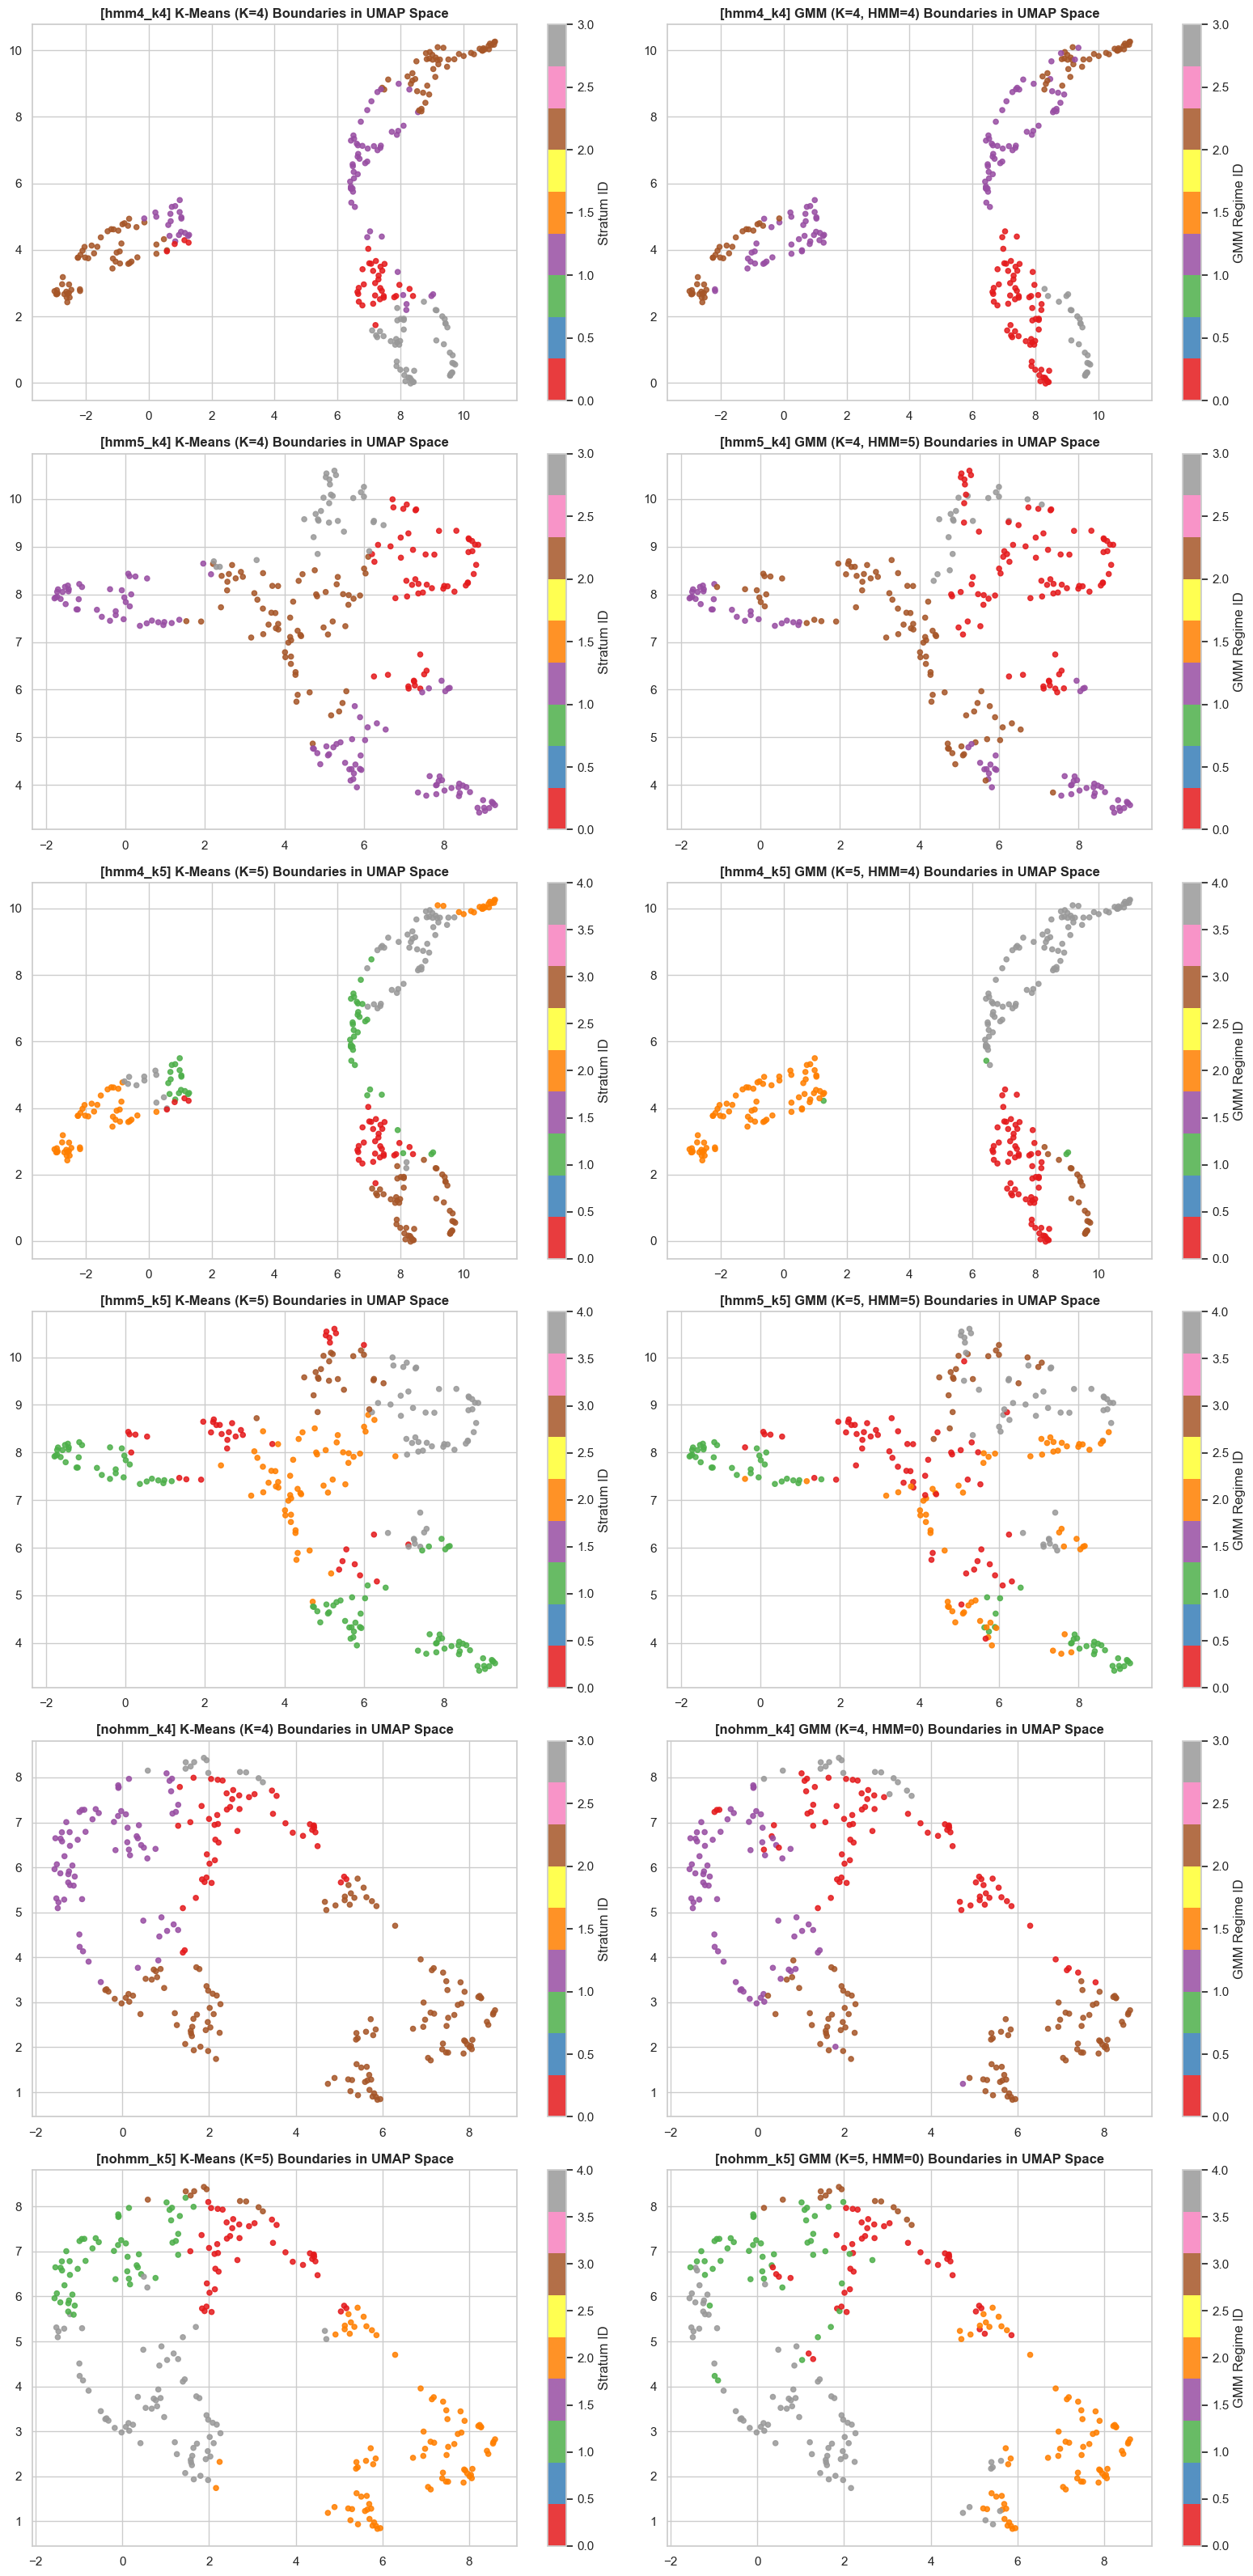

In [13]:
fig, axes = plt.subplots(6, 2, figsize=(16, 32))

for idx, (prefix, h_states, g_k) in enumerate(experiments):
    res = exp_results[prefix]
    X_sc = res["X_scaled"]
    df_p = res["df_profiles"]
    
    reducer = umap.UMAP(random_state=SEED, n_neighbors=15, min_dist=0.1)
    embedding = reducer.fit_transform(X_sc)
    
    sc1 = axes[idx, 0].scatter(embedding[:, 0], embedding[:, 1], c=df_p["stratum"], cmap="Set1", s=20, alpha=0.85)
    axes[idx, 0].set_title(f"[{prefix}] K-Means (K={g_k}) Boundaries in UMAP Space", fontsize=12, fontweight="bold")
    plt.colorbar(sc1, ax=axes[idx, 0], label="Stratum ID")
    
    sc2 = axes[idx, 1].scatter(embedding[:, 0], embedding[:, 1], c=df_p["gmm_regime"], cmap="Set1", s=20, alpha=0.85)
    axes[idx, 1].set_title(f"[{prefix}] GMM (K={g_k}, HMM={h_states}) Boundaries in UMAP Space", fontsize=12, fontweight="bold")
    plt.colorbar(sc2, ax=axes[idx, 1], label="GMM Regime ID")

plt.tight_layout()
plt.show()


## 6. Comprehensive Regime Profiling & Feature Boxplots (All 6 Experiment Versions)

Below we render 4-panel feature distribution boxplots for all six experiment versions (`hmm4_k4`, `hmm5_k4`, `hmm4_k5`, `hmm5_k5`, `nohmm_k4`, `nohmm_k5`).


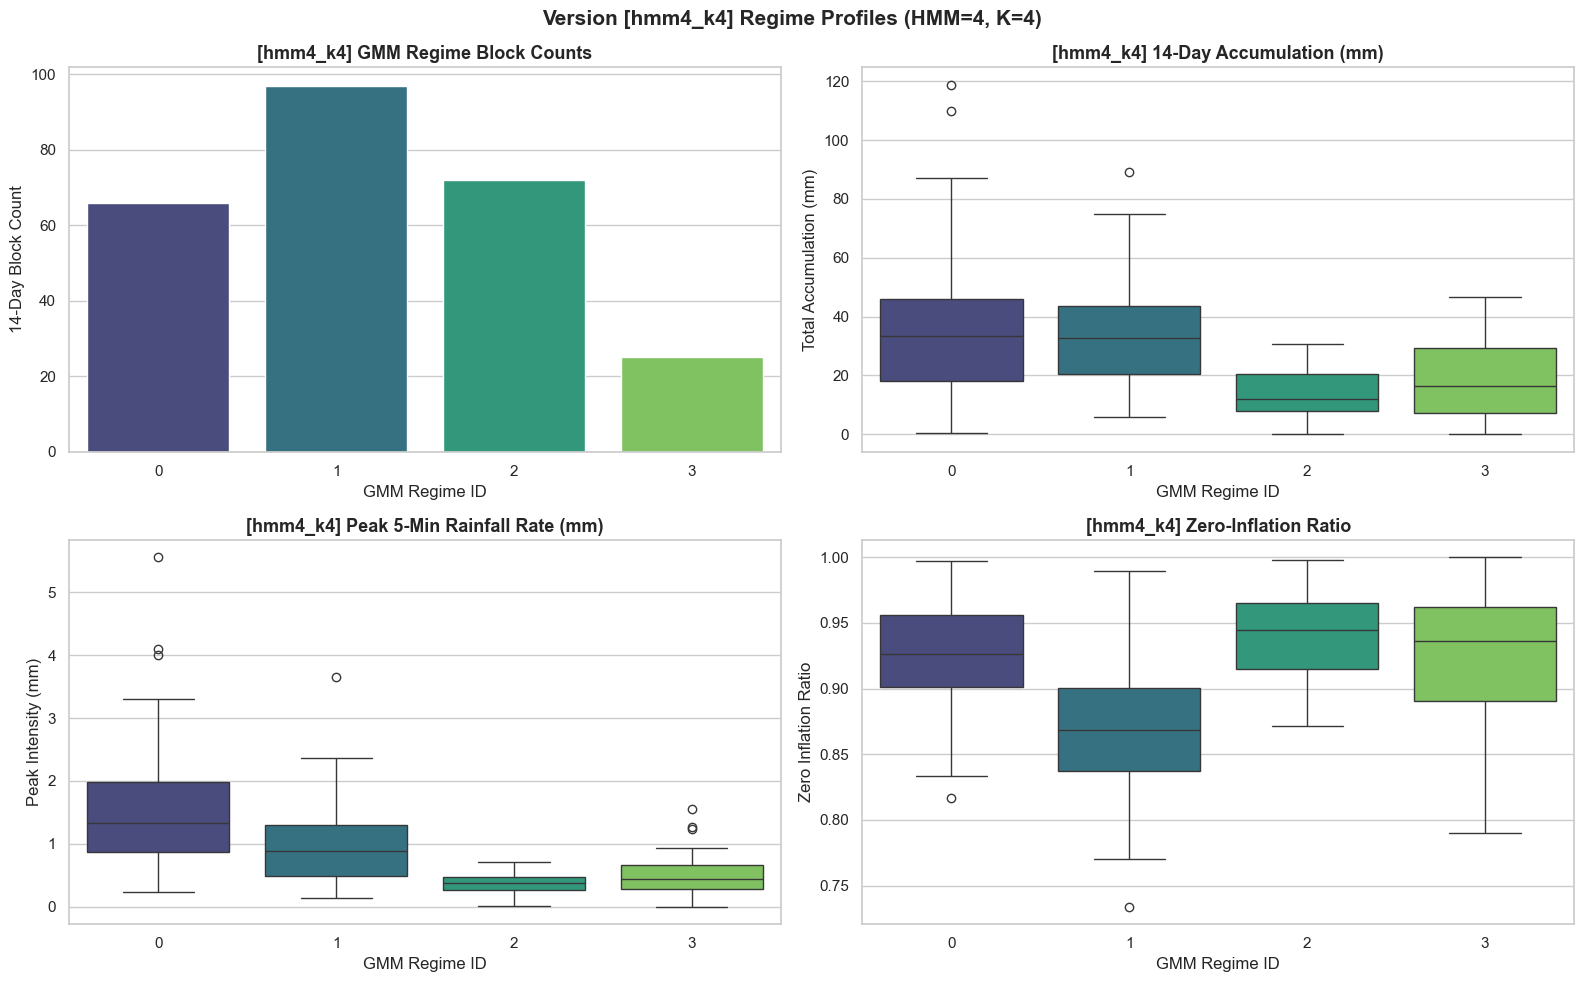

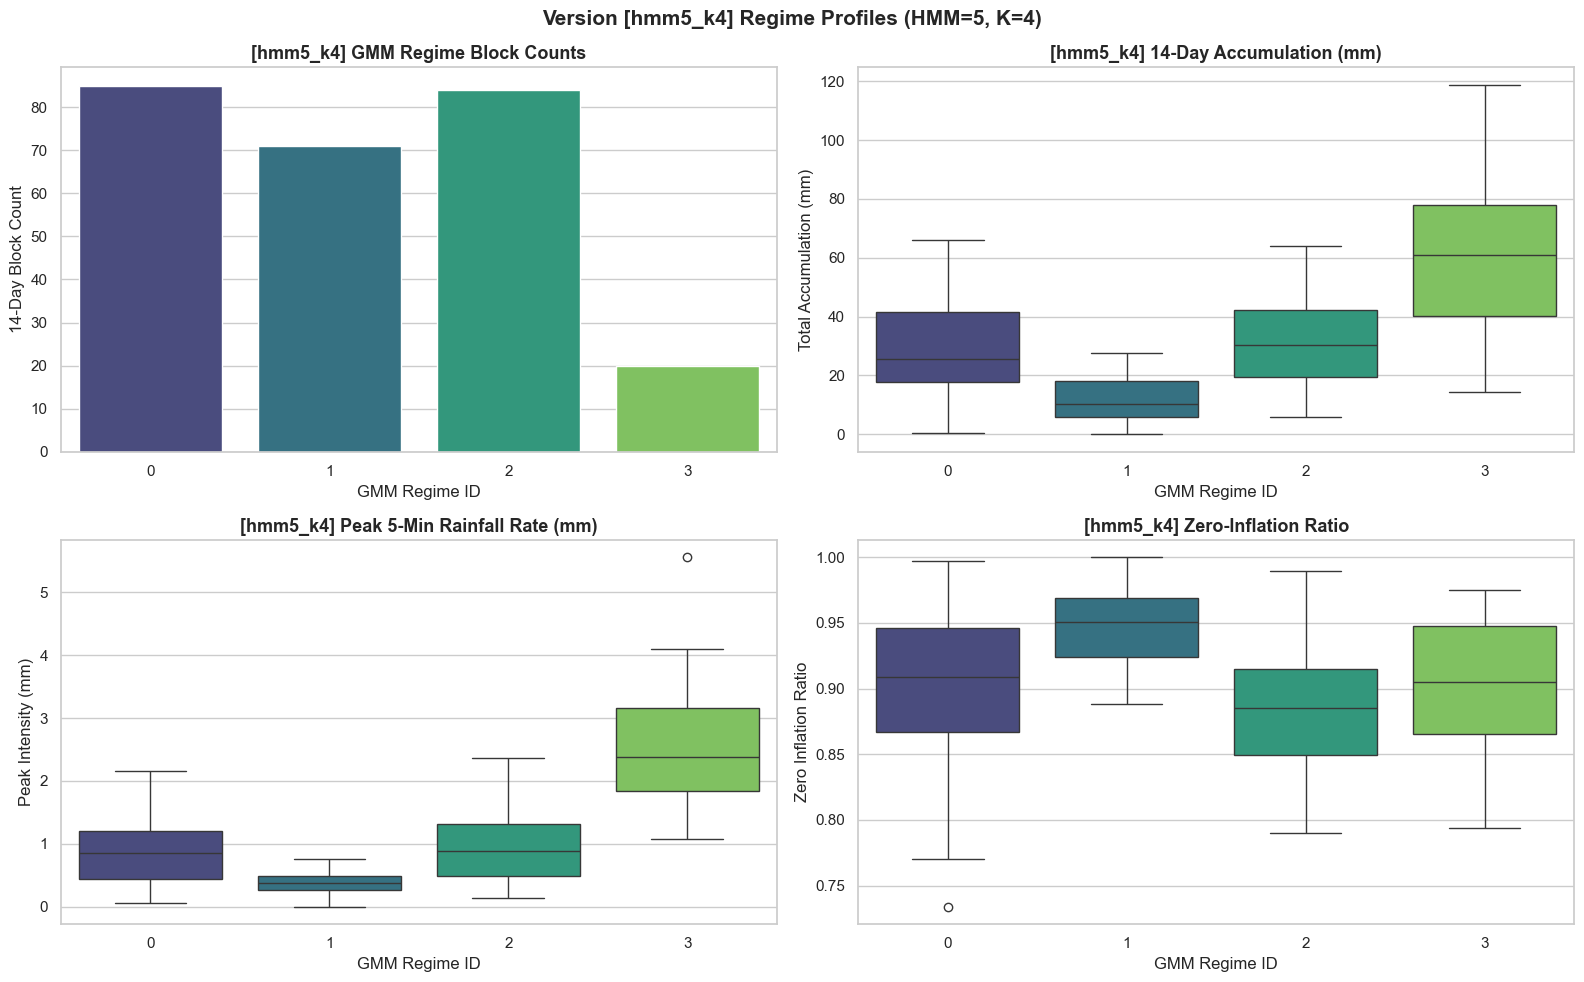

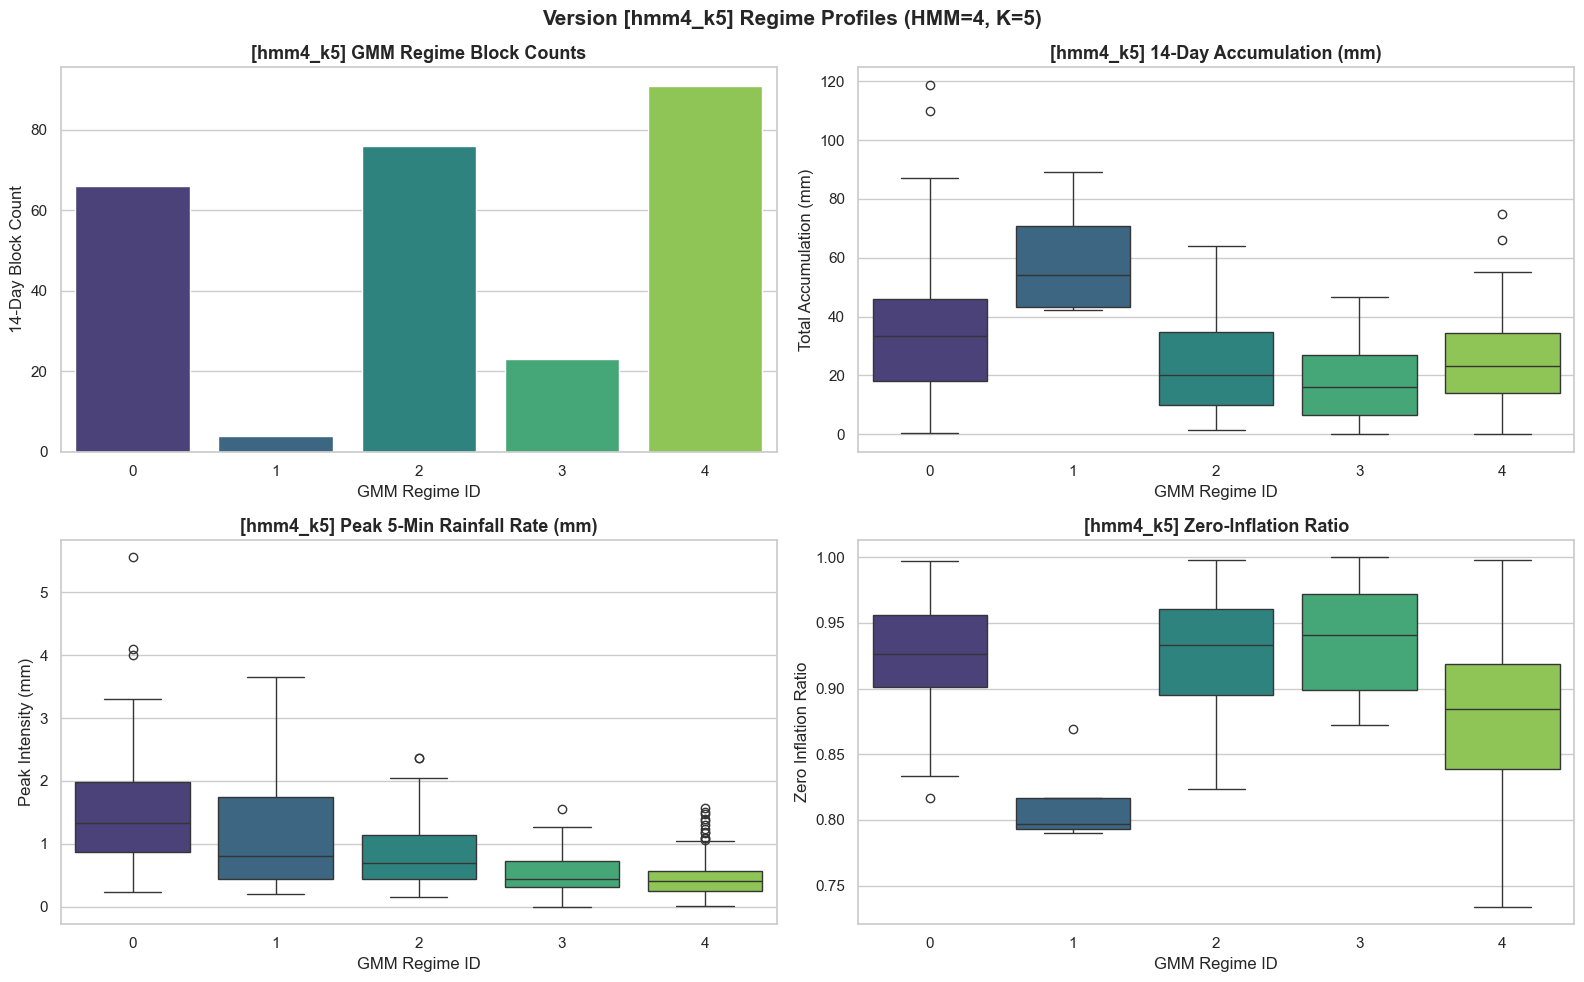

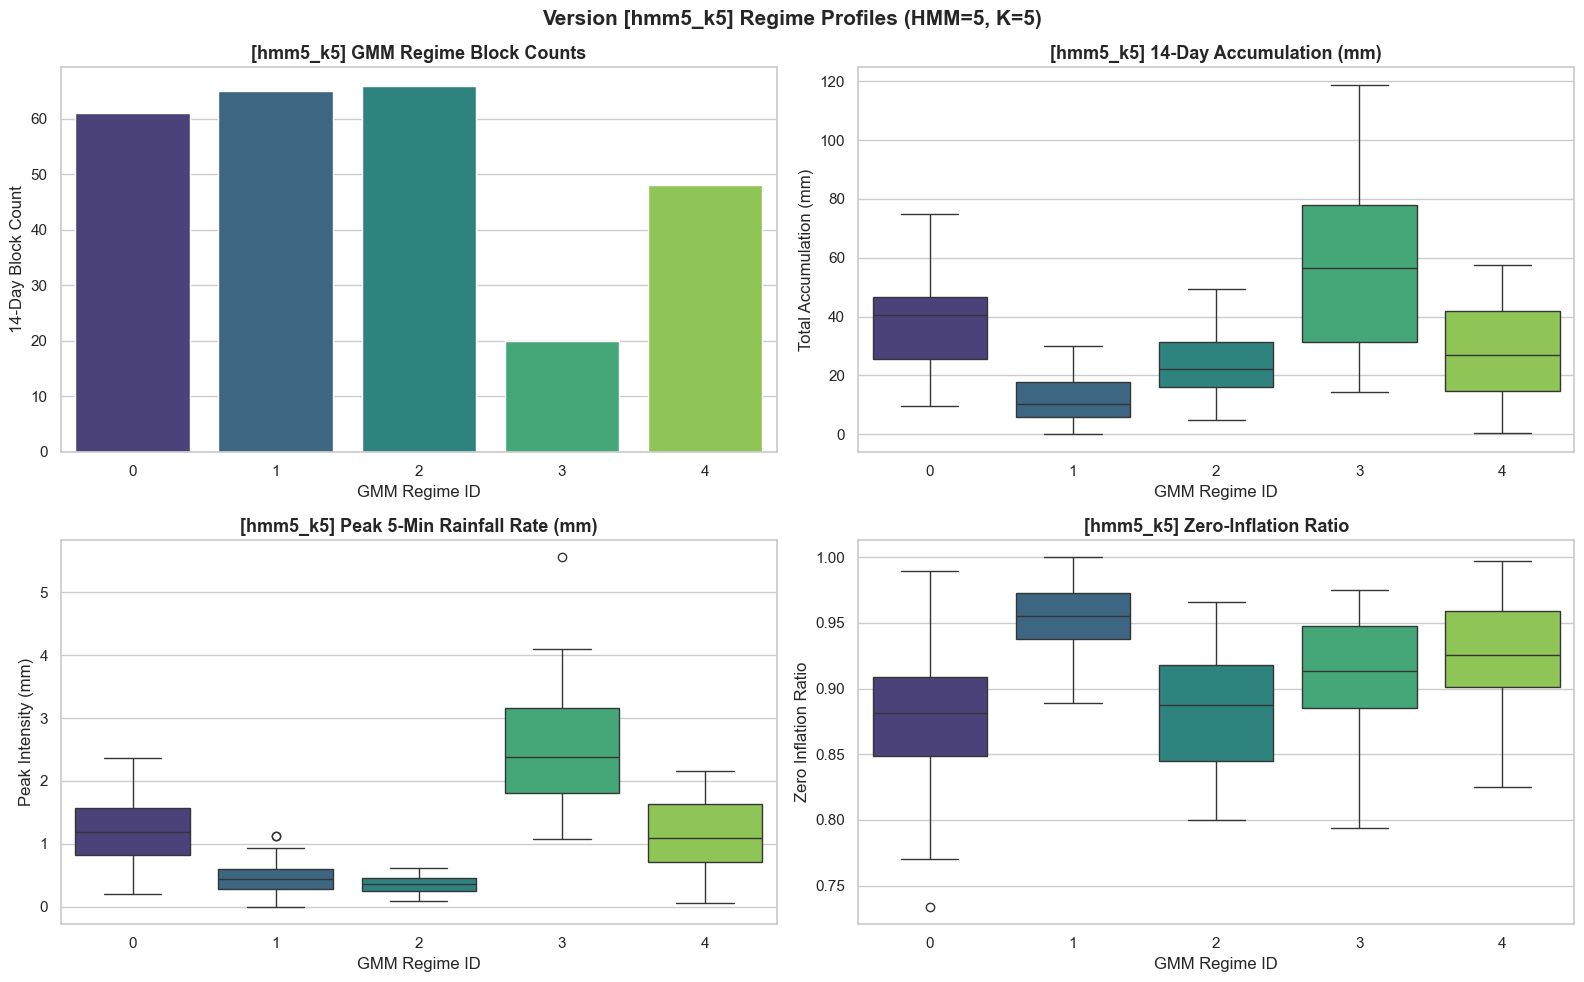

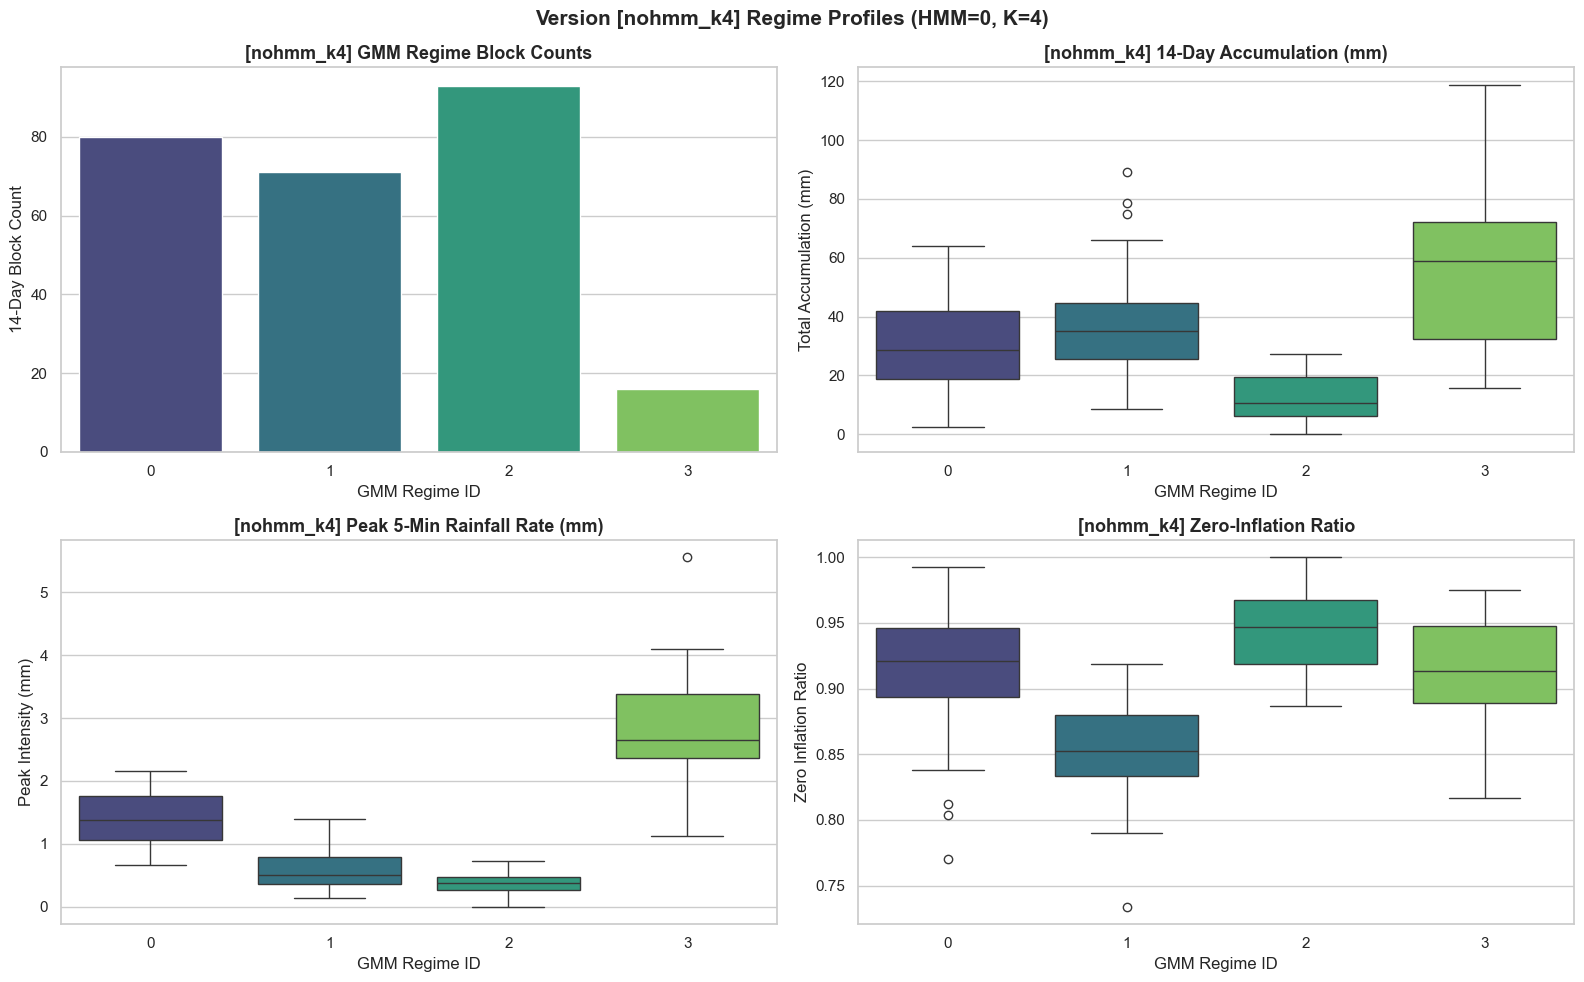

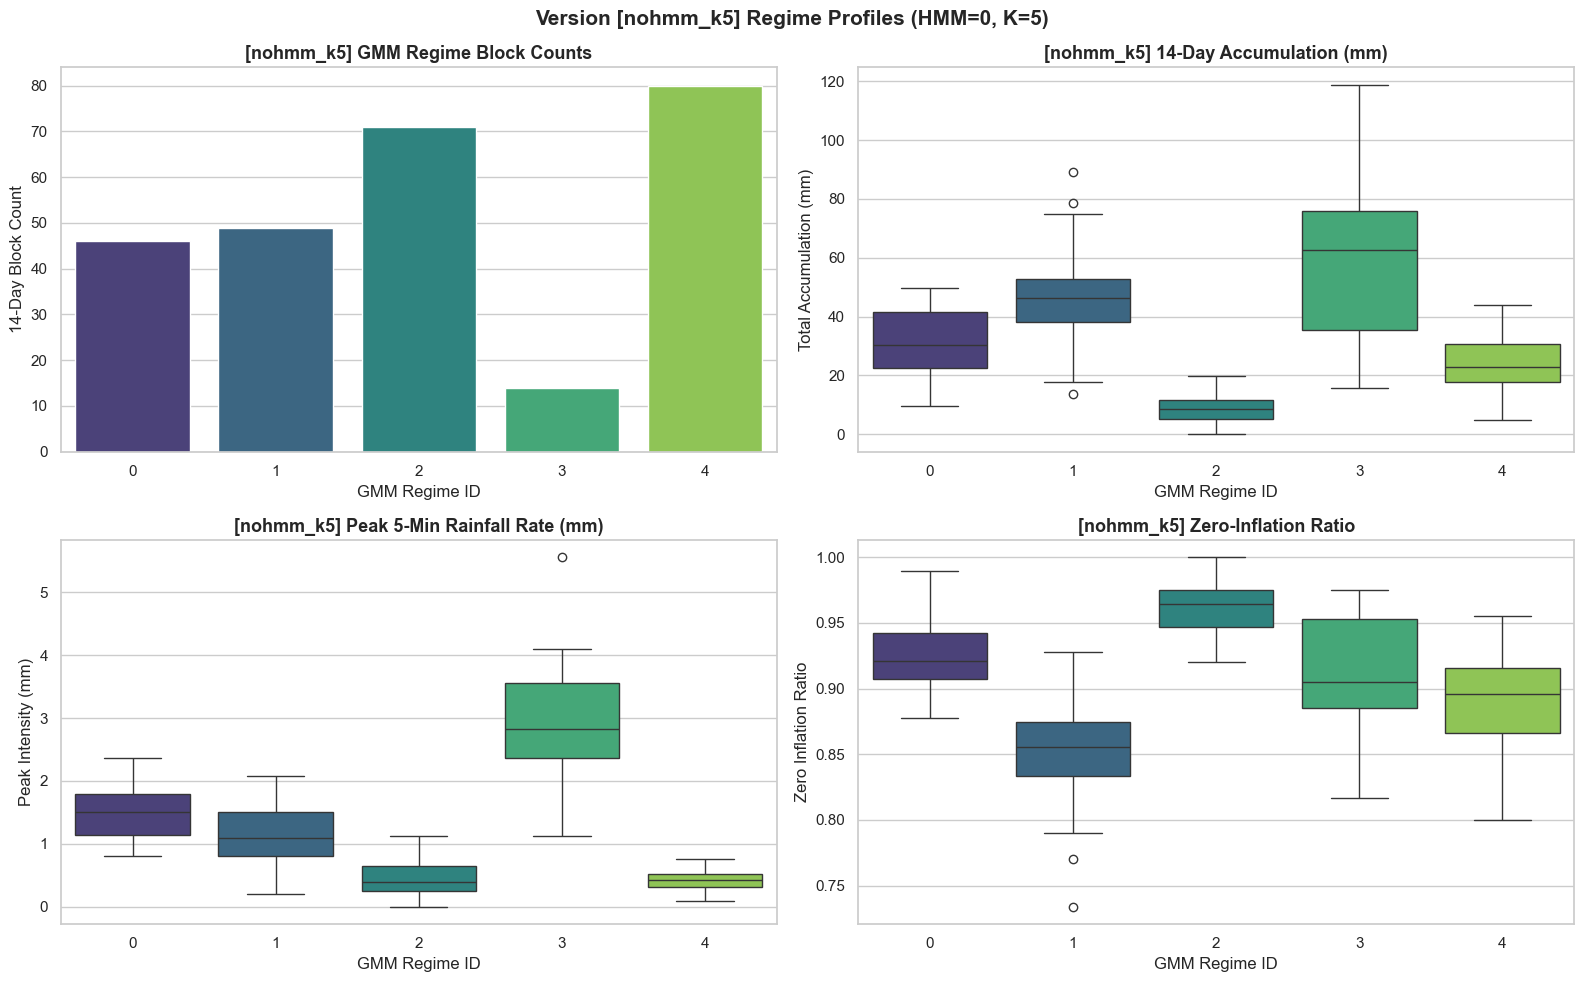

In [15]:
for prefix, h_states, g_k in experiments:
    df_p = exp_results[prefix]["df_profiles"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Version [{prefix}] Regime Profiles (HMM={h_states}, K={g_k})", fontsize=15, fontweight="bold")
    
    sns.countplot(data=df_p, x="gmm_regime", palette="viridis", ax=axes[0, 0])
    axes[0, 0].set_title(f"[{prefix}] GMM Regime Block Counts", fontsize=13, fontweight="bold")
    axes[0, 0].set_xlabel("GMM Regime ID")
    axes[0, 0].set_ylabel("14-Day Block Count")
    
    sns.boxplot(data=df_p, x="gmm_regime", y="total_accumulation", palette="viridis", ax=axes[0, 1])
    axes[0, 1].set_title(f"[{prefix}] 14-Day Accumulation (mm)", fontsize=13, fontweight="bold")
    axes[0, 1].set_xlabel("GMM Regime ID")
    axes[0, 1].set_ylabel("Total Accumulation (mm)")
    
    sns.boxplot(data=df_p, x="gmm_regime", y="peak_intensity", palette="viridis", ax=axes[1, 0])
    axes[1, 0].set_title(f"[{prefix}] Peak 5-Min Rainfall Rate (mm)", fontsize=13, fontweight="bold")
    axes[1, 0].set_xlabel("GMM Regime ID")
    axes[1, 0].set_ylabel("Peak Intensity (mm)")
    
    sns.boxplot(data=df_p, x="gmm_regime", y="zero_inflation", palette="viridis", ax=axes[1, 1])
    axes[1, 1].set_title(f"[{prefix}] Zero-Inflation Ratio", fontsize=13, fontweight="bold")
    axes[1, 1].set_xlabel("GMM Regime ID")
    axes[1, 1].set_ylabel("Zero Inflation Ratio")
    
    plt.tight_layout()
    plt.show()


## 7. Conclusion & Dataset Version Deployment Summary

- **Comprehensive Experiment Matrix**: Successfully implemented a modular tracking pipeline executing six versions (`hmm4_k4`, `hmm5_k4`, `hmm4_k5`, `hmm5_k5`, `nohmm_k4`, `nohmm_k5`).
- **Version-Specific Subdirectory Exports**: All datasets (`train_{version}.csv`, `val_{version}.csv`, `test_{version}.csv`, `astlingen_block_profiles_{version}.csv`) are exported under `../data/rainfall/astlingen/splits/14day_blocks/{version}/`.
